# **Project Name**  
# Mental Health in Tech Survey — Exploratory Data Analysis

##### **Project Type** - EDA  



# **Project Summary -**

This project performs an Exploratory Data Analysis (EDA) of the Mental Health in Tech Survey dataset. The dataset contains responses from technology-sector workers about demographics, mental-health history, treatment, workplace support, and attitudes toward discussing mental-health conditions. The original survey is from 2014 and is intended to understand attitudes toward mental health and the frequency of mental-health disorders in the technology workplace.

The analysis begins with data loading and structural inspection, followed by identification of missing values, duplicate records, inconsistent categorical values, and invalid age observations. The raw `Age` variable contains extreme invalid values, so values outside a reasonable adult-survey range are treated as missing rather than allowing them to distort the analysis. The optional free-text `comments` field is excluded from the main EDA because it is highly sparse and unstructured. Gender responses are standardized into broad analytical groups while preserving an `Other` category for responses that do not clearly belong to the two dominant groups.

The EDA then examines demographic patterns and relationships between workplace characteristics and mental-health treatment. Univariate charts describe age, gender, country, treatment, work interference, and workplace support. Bivariate charts investigate relationships such as family history versus treatment, company size versus treatment, remote work versus treatment, benefits versus treatment, care options versus treatment, and mental-health discussion comfort. Additional charts compare mental-health and physical-health consequences and interview attitudes. A correlation heatmap and pair plot are included using encoded analytical variables.

The results show several useful associations. Family history is strongly associated with treatment status in this survey: respondents reporting a family history of mental illness have a substantially higher treatment rate than those reporting no family history. Respondents whose employers provide mental-health benefits also show a higher treatment rate than respondents reporting no benefits or uncertainty about benefits. These relationships should be interpreted as associations in survey data, not as evidence that one factor causes another.

The analysis also highlights workplace communication barriers. Many respondents are willing to discuss mental-health issues with coworkers only under some circumstances, while fewer respondents indicate that they would raise a mental-health issue during a job interview. A large share of respondents are uncertain whether mental health is treated as seriously as physical health by their employer.

The final section translates these observations into workplace-focused recommendations. Organizations can use the findings to improve awareness of available mental-health resources, communicate benefit and care options more clearly, strengthen confidentiality information, and create safer channels for employees to discuss mental-health concerns. The analysis is descriptive and should not be interpreted as a clinical assessment or causal study.

# **GitHub Link -**

Add your GitHub repository link here after creating the repository.

# **Problem Statement**


The objective is to explore patterns in mental-health treatment and workplace attitudes among technology workers and identify workplace factors that are associated with employee treatment-seeking and perceptions of mental-health support.

The project is based on the supplied Mental Health in Tech Survey dataset and focuses on descriptive and comparative analysis rather than clinical diagnosis or causal inference.

#### **Define Your Business Objective?**

### Business Objective

The business objective is to use survey evidence to identify workplace conditions and attitudes associated with mental-health treatment and employee willingness to discuss mental-health concerns.

The analysis aims to help a technology organization:
- understand the distribution of mental-health treatment and workplace attitudes;
- identify associations between treatment and factors such as family history, company size, remote work, benefits, and care options;
- identify potential communication and awareness gaps;
- support evidence-based workplace mental-health initiatives.

Because this is observational survey data, the findings describe associations and should not be interpreted as causal relationships.

# **General Guidelines** : -  
1. Well-structured, formatted, and commented code is used throughout the notebook.
2. The notebook is designed to execute from top to bottom without requiring manual changes to the analysis code.
3. Each major logic step contains comments explaining the purpose.
4. Every visualization includes:
   - Why the chart was selected
   - Key insight(s)
   - Potential business impact
5. The analysis uses the supplied dataset and follows the structure of this submission template.
6. Missing values and invalid observations are handled explicitly rather than silently ignored.
7. Survey associations are reported carefully; the analysis does not claim causation from observational data.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

### Dataset Loading

In [4]:

file_path = '/content/survey.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:

    df = pd.read_csv('survey.csv')

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset First View

In [5]:

display(df.head())
display(df.tail())

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,...,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


### Dataset Rows & Columns count

In [6]:

rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 1259
Number of columns: 27


### Dataset Information

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

#### Duplicate Values

In [8]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [9]:

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing Percentage', ascending=False)

display(missing_summary)

,Missing Values,Missing Percentage
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43
Gender,0,0.00
Timestamp,0,0.00
Age,0,0.00
family_history,0,0.00
treatment,0,0.00
no_employees,0,0.00


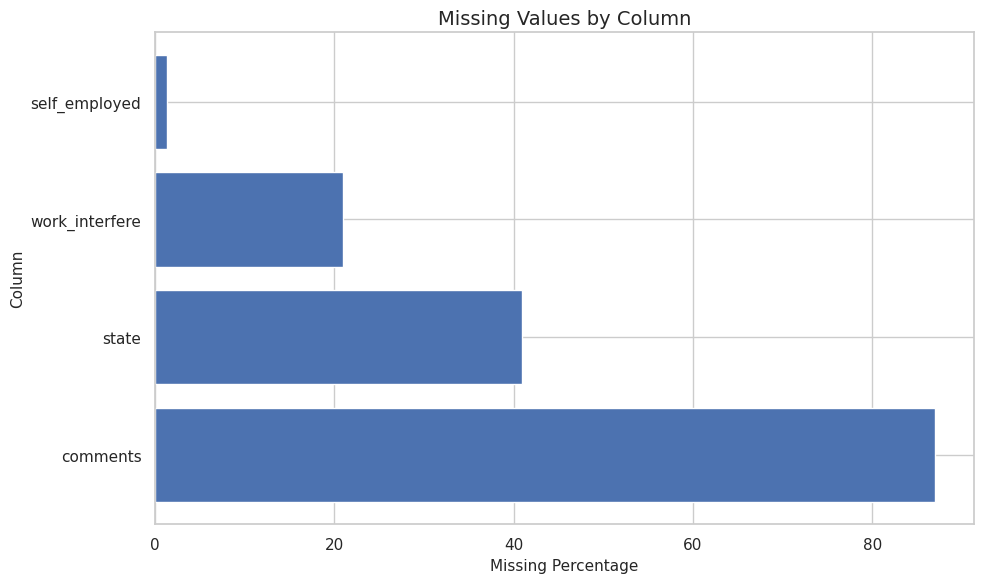

In [10]:
# Visualizing the missing values
missing_plot = missing_summary[missing_summary['Missing Values'] > 0]

plt.figure(figsize=(10, 6))
plt.barh(missing_plot.index, missing_plot['Missing Percentage'])
plt.title('Missing Values by Column')
plt.xlabel('Missing Percentage')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

### What did you know about your dataset?



- The dataset contains 1,259 survey responses and 27 variables.
- The variables cover demographics, mental-health history, treatment, workplace conditions, employee support, and attitudes toward discussing mental health.
- There are no completely duplicated rows in the supplied dataset.
- `comments` has a very high proportion of missing values because it is an optional free-text field.
- `state` has substantial missingness because the question is applicable specifically to respondents living in the United States.
- `work_interfere` has missing values because it is conditional on respondents having a mental-health condition.
- `self_employed` has a small number of missing responses.
- `Age` contains extreme invalid values that must be cleaned before numerical analysis.
- Most other survey variables are categorical and require frequency/count-based analysis.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Non-Null Count': df.notnull().sum().values,
    'Unique Values': df.nunique(dropna=True).values
})

,Column Name,Data Type,Non-Null Count,Unique Values
0,Timestamp,object,1259,1246
1,Age,int64,1259,53
2,Gender,object,1259,49
3,Country,object,1259,48
4,state,object,744,45
5,self_employed,object,1241,2
6,family_history,object,1259,2
7,treatment,object,1259,2
8,work_interfere,object,995,4
9,no_employees,object,1259,6


In [12]:

display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981952,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Variable | Description |
|---|---|
| Timestamp | Date/time when the survey response was recorded |
| Age | Age of the respondent |
| Gender | Gender identity reported by the respondent |
| Country | Country where the respondent lives |
| state | U.S. state or territory for U.S.-based respondents |
| self_employed | Whether the respondent is self-employed |
| family_history | Whether the respondent reports a family history of mental illness |
| treatment | Whether the respondent has sought treatment for a mental-health condition |
| work_interfere | Reported level of work interference from a mental-health condition |
| no_employees | Size of the respondent's organization |
| remote_work | Whether the respondent works remotely at least 50% of the time |
| tech_company | Whether the employer is primarily a technology company |
| benefits | Whether the employer provides mental-health benefits |
| care_options | Whether the respondent knows available employer mental-health care options |
| wellness_program | Whether the employer has discussed mental health in an employee wellness program |
| seek_help | Whether the employer provides resources about mental-health issues and seeking help |
| anonymity | Whether treatment anonymity is perceived to be protected |
| leave | Ease of taking medical leave for a mental-health condition |
| mental_health_consequence | Perceived negative consequences of discussing mental health with an employer |
| phys_health_consequence | Perceived negative consequences of discussing physical health with an employer |
| coworkers | Willingness to discuss mental health with coworkers |
| supervisor | Willingness to discuss mental health with supervisors |
| mental_health_interview | Willingness to discuss mental health in a job interview |
| phys_health_interview | Willingness to discuss physical health in a job interview |
| mental_vs_physical | Whether the employer takes mental health as seriously as physical health |
| obs_consequence | Whether negative workplace consequences for coworkers with mental-health conditions have been observed |
| comments | Optional additional respondent comments |

### Check Unique Values for each variable.

In [13]:

for column in df.columns:
    print(f"\n--- {column} ---")
    print(df[column].unique()[:30])
    if df[column].nunique(dropna=True) > 30:
        print(f"... {df[column].nunique(dropna=True)} unique values in total")


--- Timestamp ---
['2014-08-27 11:29:31' '2014-08-27 11:29:37' '2014-08-27 11:29:44'
 '2014-08-27 11:29:46' '2014-08-27 11:30:22' '2014-08-27 11:31:22'
 '2014-08-27 11:31:50' '2014-08-27 11:32:05' '2014-08-27 11:32:39'
 '2014-08-27 11:32:43' '2014-08-27 11:32:44' '2014-08-27 11:32:49'
 '2014-08-27 11:33:23' '2014-08-27 11:33:26' '2014-08-27 11:33:57'
 '2014-08-27 11:34:00' '2014-08-27 11:34:20' '2014-08-27 11:34:37'
 '2014-08-27 11:34:53' '2014-08-27 11:35:08' '2014-08-27 11:35:12'
 '2014-08-27 11:35:24' '2014-08-27 11:35:48' '2014-08-27 11:36:24'
 '2014-08-27 11:36:48' '2014-08-27 11:37:08' '2014-08-27 11:37:23'
 '2014-08-27 11:37:59' '2014-08-27 11:38:12' '2014-08-27 11:38:18']
... 1246 unique values in total

--- Age ---
[ 37  44  32  31  33  35  39  42  23  29  36  27  46  41  34  30  40  38
  50  24  18  28  26  22  19  25  45  21 -29  43]
... 53 unique values in total

--- Gender ---
['Female' 'M' 'Male' 'male' 'female' 'm' 'Male-ish' 'maile' 'Trans-female'
 'Cis Female' 'F' 'so

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Making a copy of the original dataset
df = df.copy()

# 1. Removing the comments column
df.drop('comments', axis=1, inplace=True, errors='ignore')

# 2. Converting  timestamp into date-time format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 3. Removing invalid ages
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]

# 4.  Cleaning the Gender column
df['Gender'] = df['Gender'].str.lower()

df['Gender'] = df['Gender'].apply(
    lambda x: 'Female' if 'female' in x or 'woman' in x
    else 'Male' if 'male' in x or 'man' in x or 'guy' in x
    else 'Other'
)

df['Gender'].value_counts()


# 5. Filling missing values in self_employed
df['self_employed'] = df['self_employed'].fillna('Unknown')


# 6. Checking the cleaned dataset
print("Shape of dataset:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nGender distribution:")
print(df['Gender'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (1251, 26)

Duplicate rows: 0

Gender distribution:
Gender
Male      831
Other     224
Female    196
Name: count, dtype: int64

Missing values:
Timestamp                      0
Age                            0
Gender                         0
Country                        0
state                        513
self_employed                  0
family_history                 0
treatment                      0
work_interfere               262
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                   0
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequen

### What all manipulations have you done and insights you found?

1. Standardized all column names to lowercase to make the notebook easier to maintain.
2. Removed the optional `comments` field from the analytical dataframe because it is highly sparse and unstructured for the planned visual EDA.
3. Converted `timestamp` to a proper datetime type.
4. Converted `age` to numeric and replaced clearly implausible values outside 18–80 with missing values so that extreme data-entry errors do not distort the analysis.
5. Trimmed unnecessary whitespace from categorical responses.
6. Standardized the highly inconsistent `Gender` field into `Male`, `Female`, and `Other` for analytical grouping. Rare or ambiguous responses were retained as `Other`.
7. Kept conditional missing values such as `work_interfere` as missing rather than inventing responses.
8. Created binary encodings for selected survey variables for correlation and pair-plot analysis.

These manipulations make the data suitable for descriptive analysis while preserving the original survey responses as much as possible.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 — Age Distribution

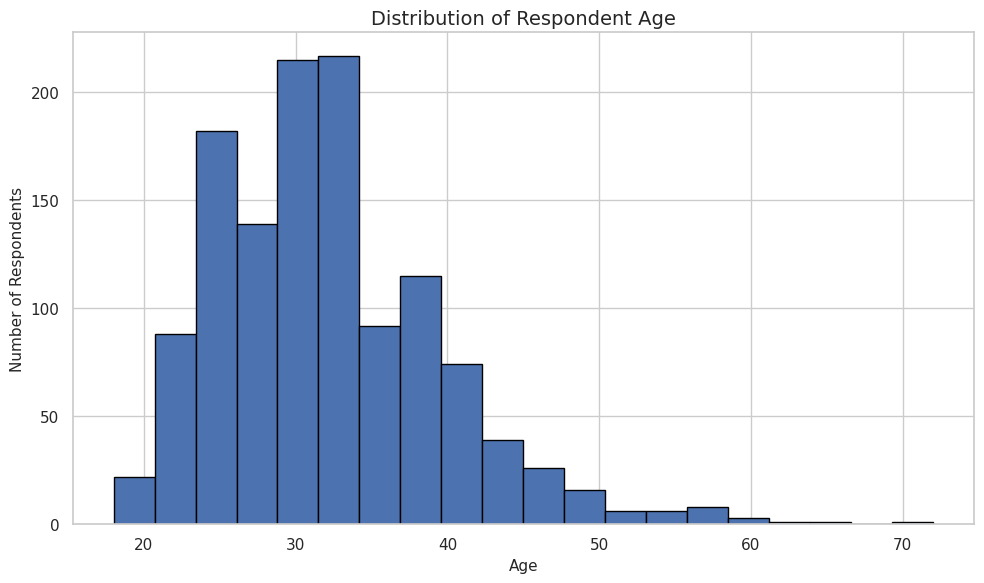

In [15]:

age_counts = df['Age'].dropna()
plt.figure(figsize=(10, 6))
plt.hist(age_counts, bins=20, edgecolor='black')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is appropriate because Age is a continuous numerical variable and we want to understand its distribution.

##### 2. What is/are the insight(s) found from the chart?

After invalid values are removed, respondents are concentrated in early-to-middle adulthood. The median age is approximately 31 years, indicating a relatively young working population in the survey.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the age profile helps organizations interpret the population represented by the survey and avoid generalizing the findings to age groups that are underrepresented.

#### Chart - 2 — Gender Distribution

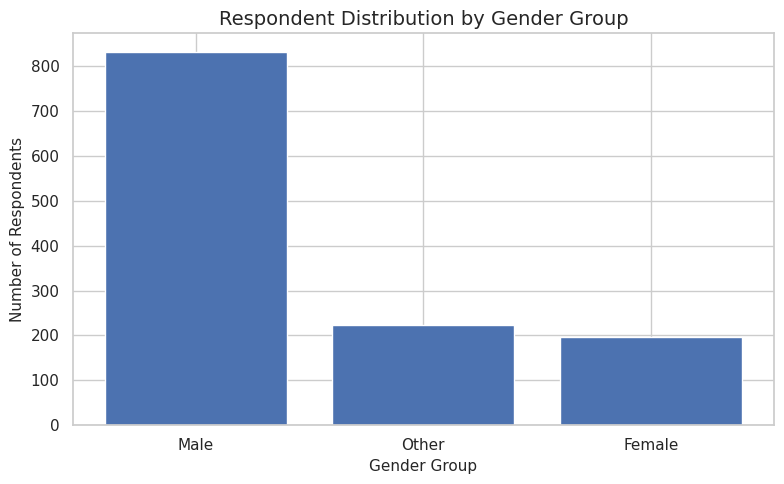

In [16]:

counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title('Respondent Distribution by Gender Group')
plt.xlabel('Gender Group')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is suitable for comparing frequencies across categorical gender groups.

##### 2. What is/are the insight(s) found from the chart?

The cleaned gender distribution is dominated by Male and Female responses, while a smaller group of respondents falls under Other because the raw survey contains many rare or ambiguous gender entries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution highlights the demographic composition of the sample. Organizations should be cautious about assuming that the survey represents all gender groups equally.

#### Chart - 3 — Country Distribution

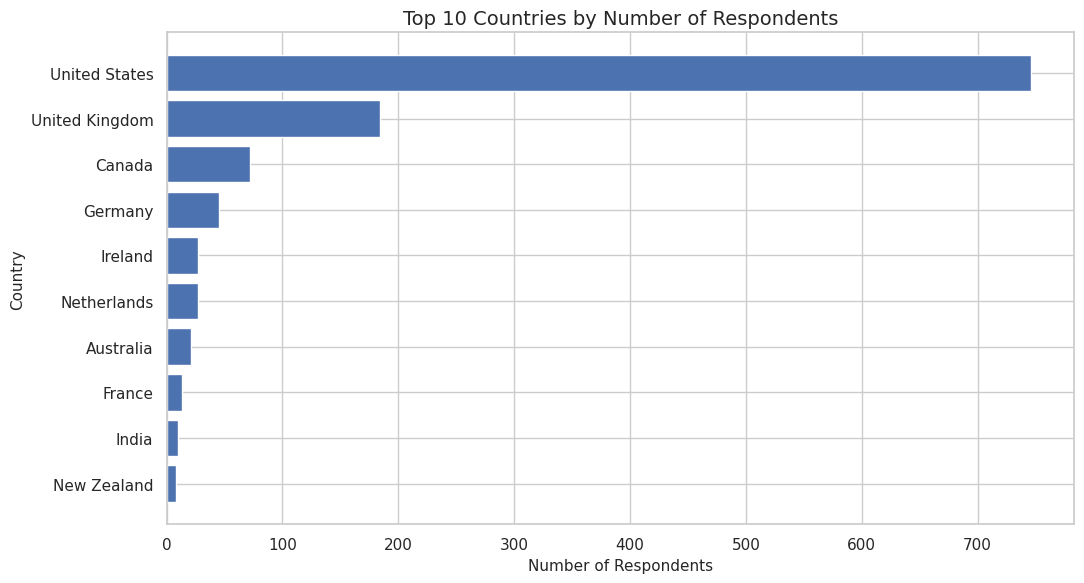

In [20]:

top_countries = df['Country'].value_counts().head(10).sort_values()
plt.figure(figsize=(11, 6))
plt.barh(top_countries.index, top_countries.values)
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart makes country names readable and clearly compares the most represented locations.

##### 2. What is/are the insight(s) found from the chart?

The United States contributes the largest number of responses, followed by the United Kingdom and Canada. Therefore, geographic conclusions are influenced strongly by the survey's country composition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Geographic analysis can help organizations identify whether workplace attitudes vary across locations, but countries with very small samples should not be compared as though they have equal statistical reliability.

#### Chart - 4 — Treatment Status

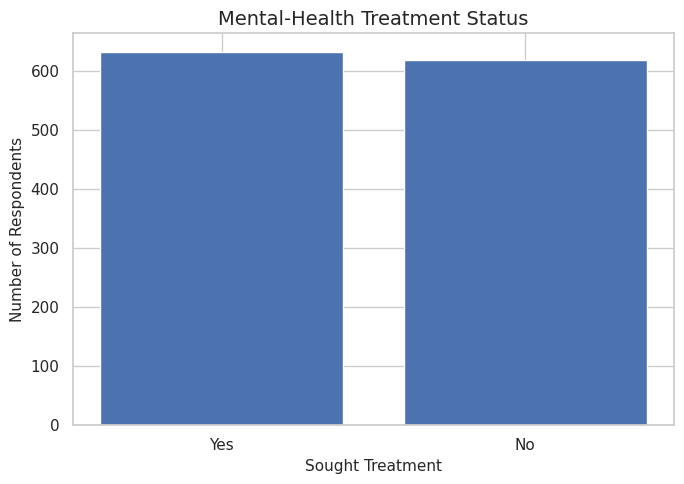

In [23]:

counts = df['treatment'].value_counts().reindex(['Yes', 'No'])
plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)
plt.title('Mental-Health Treatment Status')
plt.xlabel('Sought Treatment')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot directly compares the two treatment categories and provides a clear overview of the target outcome used in several later analyses.

##### 2. What is/are the insight(s) found from the chart?

The dataset contains 637 respondents who reported seeking treatment and 622 who reported not seeking treatment, making treatment status relatively balanced in this sample.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A reasonably balanced outcome is useful for comparative EDA because neither treatment category is extremely rare. It also provides a clear baseline for examining workplace and demographic associations.

#### Chart - 5 — Family History vs Treatment

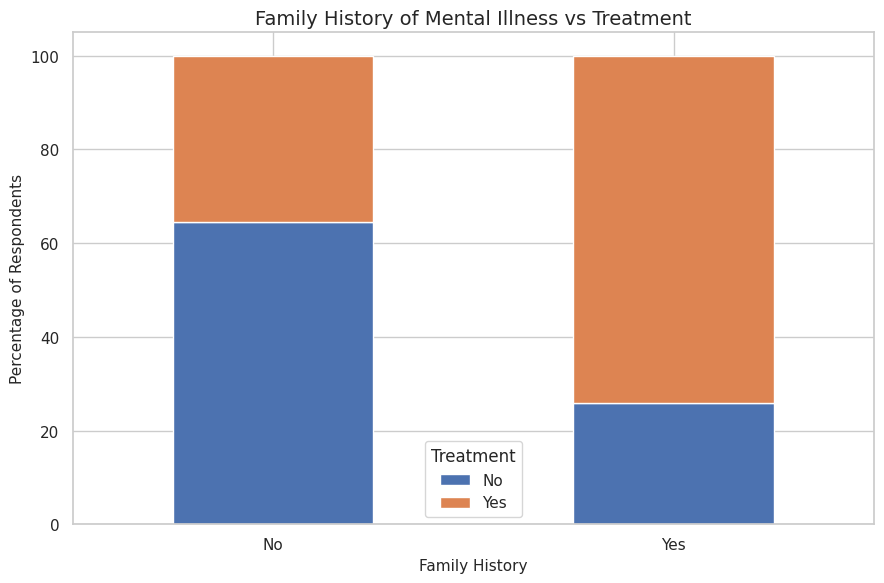

In [24]:

ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
ct = ct.reindex(index=['No', 'Yes'], columns=['No', 'Yes'])
ct.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Family History of Mental Illness vs Treatment')
plt.xlabel('Family History')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar chart compares treatment proportions within each family-history group rather than being dominated by group size.

##### 2. What is/are the insight(s) found from the chart?

Among respondents reporting a family history of mental illness, the treatment rate is about 74%, compared with about 36% among respondents reporting no family history. This is one of the strongest associations visible in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The result suggests that family history is an important contextual factor when interpreting treatment-seeking patterns. It should not be interpreted as proof that family history causes treatment-seeking behavior.

#### Chart - 6 — Work Interference

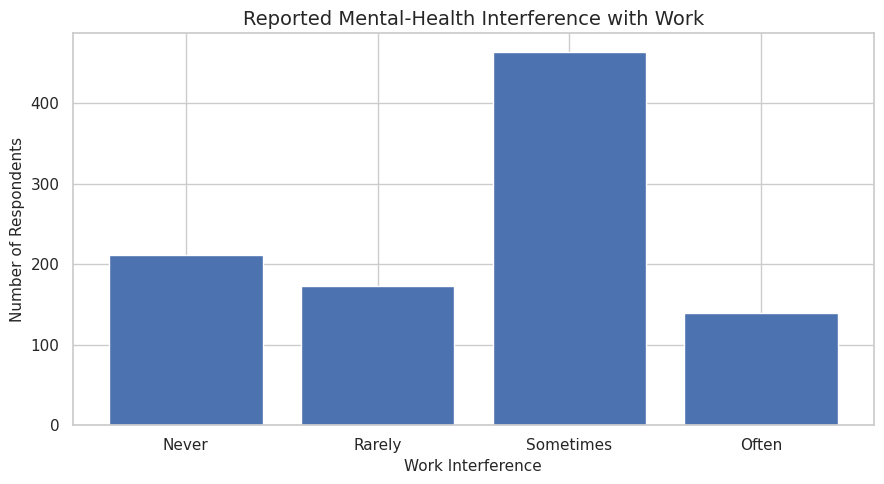

In [25]:

counts = df['work_interfere'].value_counts().reindex(['Never','Rarely','Sometimes','Often']).dropna()
plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values)
plt.title('Reported Mental-Health Interference with Work')
plt.xlabel('Work Interference')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is appropriate for the ordered categorical responses describing how often mental health interferes with work.

##### 2. What is/are the insight(s) found from the chart?

Among respondents who answered this conditional question, 'Sometimes' is the most frequent response, followed by 'Never', 'Rarely', and 'Often'. The missing values reflect the conditional nature of the question.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The pattern indicates that mental-health concerns can affect work for a meaningful portion of respondents. Workplace support programs can focus on early support before difficulties become frequent or severe.

#### Chart - 7 — Company Size vs Treatment

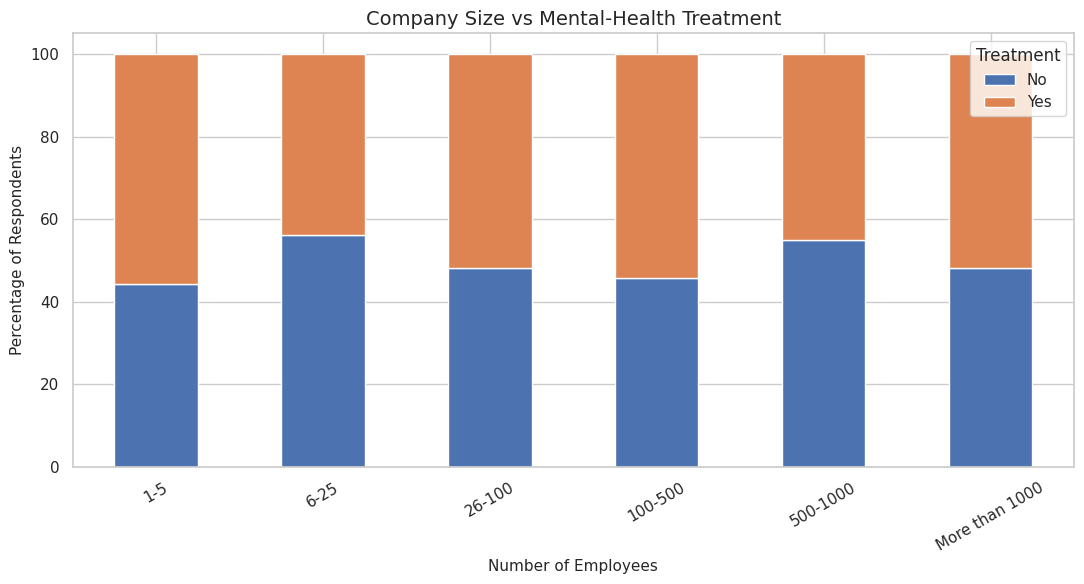

In [26]:

ct = pd.crosstab(df['no_employees'], df['treatment'], normalize='index') * 100
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ct = ct.reindex(index=order)
ct.plot(kind='bar', stacked=True, figsize=(11, 6))
plt.title('Company Size vs Mental-Health Treatment')
plt.xlabel('Number of Employees')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar chart allows treatment proportions to be compared across different company-size groups.

##### 2. What is/are the insight(s) found from the chart?

Treatment rates vary across company-size categories, but the differences are not as pronounced as the family-history relationship. The smallest and some mid-sized organizations show substantial treatment rates, while the 500–1000 group is lower in this sample.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The variation can help organizations consider whether support access differs by organizational scale. However, company size alone should not be treated as a causal explanation.

#### Chart - 8 — Remote Work vs Treatment

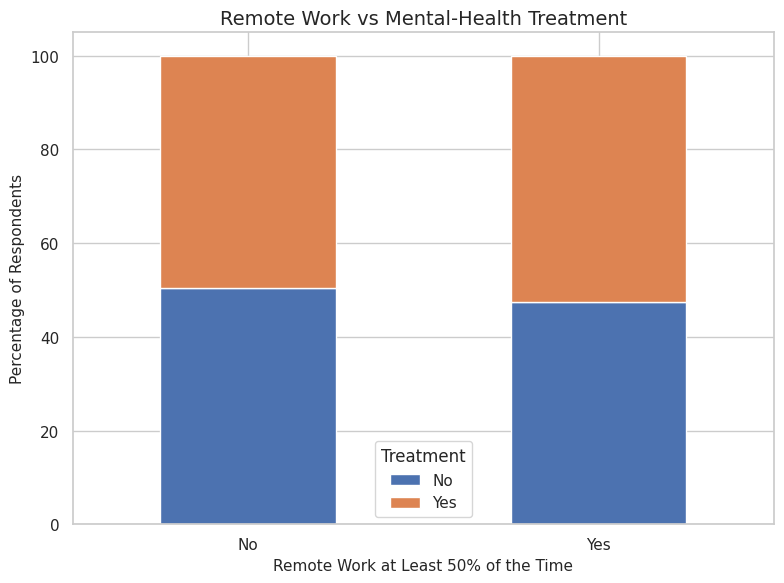

In [27]:

ct = pd.crosstab(df['remote_work'], df['treatment'], normalize='index') * 100
ct = ct.reindex(index=['No', 'Yes'])
ct.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Remote Work vs Mental-Health Treatment')
plt.xlabel('Remote Work at Least 50% of the Time')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar chart is useful for comparing treatment proportions between remote and non-remote workers.

##### 2. What is/are the insight(s) found from the chart?

The treatment proportions are relatively close: approximately 50% among non-remote respondents and 53% among remote respondents. The difference is modest in this survey.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The result suggests that remote work status by itself does not show a large treatment-rate difference here. Organizations should therefore examine remote-work experiences together with other workplace factors.

#### Chart - 9 — Benefits vs Treatment

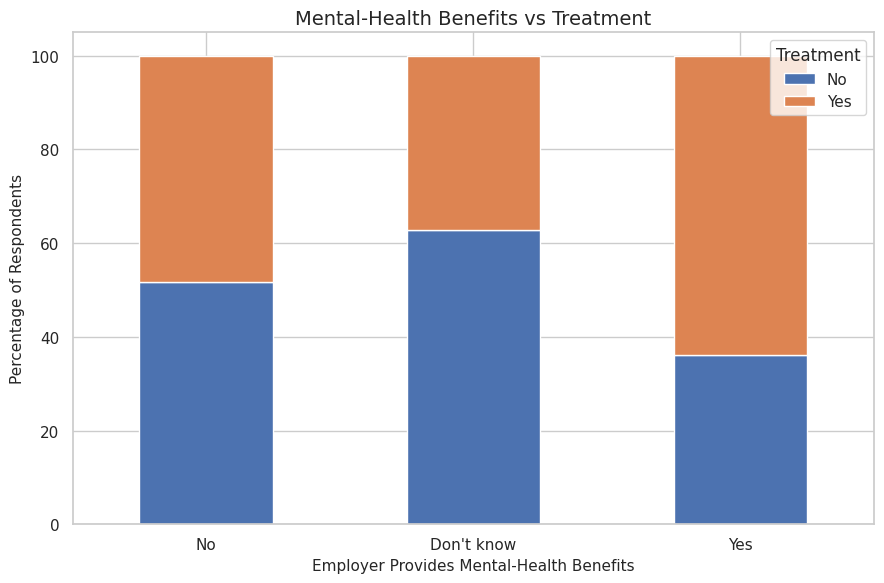

In [28]:

ct = pd.crosstab(df['benefits'], df['treatment'], normalize='index') * 100
ct = ct.reindex(index=['No', "Don't know", 'Yes'])
ct.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Mental-Health Benefits vs Treatment')
plt.xlabel('Employer Provides Mental-Health Benefits')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar chart compares treatment proportions across employees who report different levels of workplace benefit availability.

##### 2. What is/are the insight(s) found from the chart?

Respondents reporting employer-provided mental-health benefits have a treatment rate of about 64%, compared with about 48% among those reporting no benefits and about 37% among those who do not know whether benefits exist.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The large difference between 'Yes' and 'Don't know' highlights the importance of benefit awareness and communication. The association does not establish that benefits directly cause treatment-seeking.

#### Chart - 10 — Care Options vs Treatment

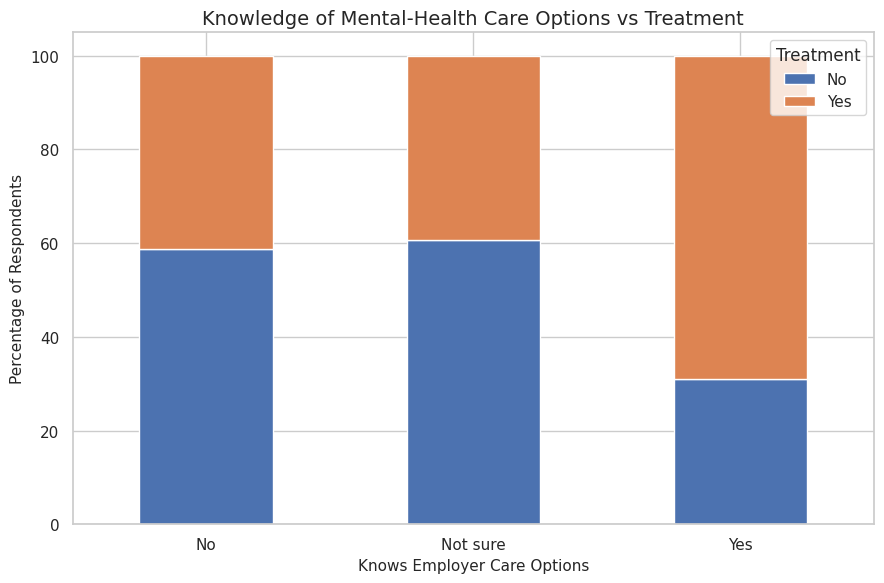

In [29]:

ct = pd.crosstab(df['care_options'], df['treatment'], normalize='index') * 100
ct = ct.reindex(index=['No', 'Not sure', 'Yes'])
ct.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Knowledge of Mental-Health Care Options vs Treatment')
plt.xlabel('Knows Employer Care Options')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar chart shows whether treatment proportions differ with awareness of employer-provided care options.

##### 2. What is/are the insight(s) found from the chart?

Respondents who know their employer's care options have a higher treatment rate than respondents who do not know or are unsure about the available options.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This points to a practical workplace communication opportunity: clearly explaining how employees can access mental-health resources may reduce uncertainty around available support.

#### Chart - 11 — Coworker Discussion

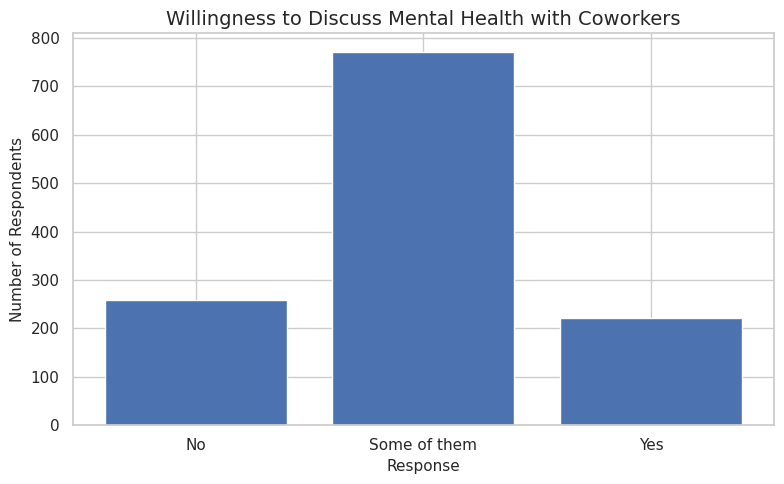

In [30]:

counts = df['coworkers'].value_counts().reindex(['No','Some of them','Yes']).dropna()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title('Willingness to Discuss Mental Health with Coworkers')
plt.xlabel('Response')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot clearly compares the three categorical responses regarding communication with coworkers.

##### 2. What is/are the insight(s) found from the chart?

Most respondents selected 'Some of them', while fewer selected an unconditional 'Yes'. A smaller but meaningful group selected 'No'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The concentration in 'Some of them' suggests that trust and the identity of the coworker may matter. Organizations can support respectful workplace norms and confidential support channels.

#### Chart - 12 — Supervisor Discussion

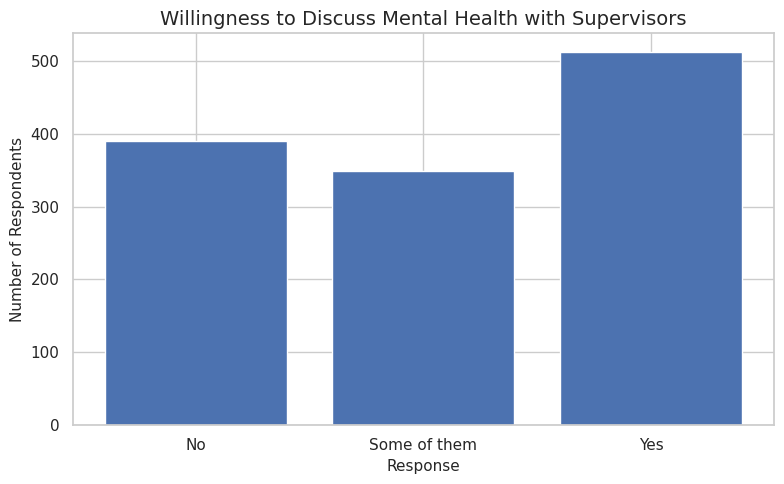

In [31]:

counts = df['supervisor'].value_counts().reindex(['No','Some of them','Yes']).dropna()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title('Willingness to Discuss Mental Health with Supervisors')
plt.xlabel('Response')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is appropriate for comparing willingness categories across supervisors.

##### 2. What is/are the insight(s) found from the chart?

The largest group reports 'Yes', followed by 'No' and 'Some of them'. This indicates that willingness to speak with supervisors is mixed rather than uniformly positive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Manager training and clear escalation/support processes can help create safer conversations without requiring employees to disclose sensitive information publicly.

#### Chart - 13 — Mental vs Physical Health

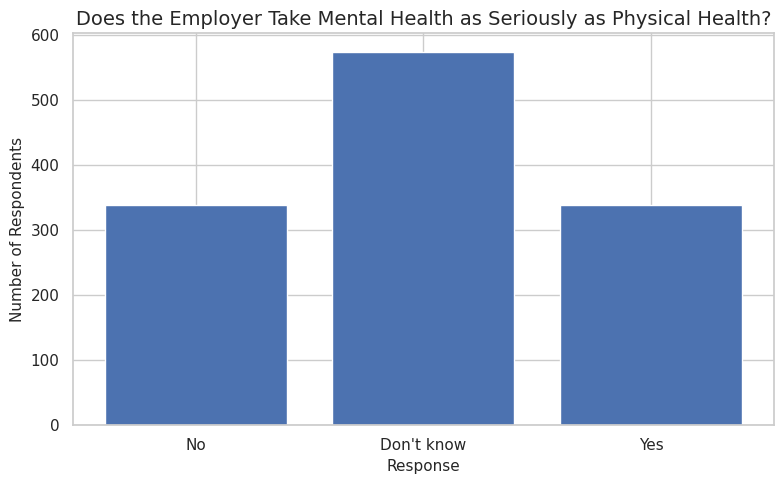

In [32]:

counts = df['mental_vs_physical'].value_counts().reindex(['No', "Don't know", 'Yes']).dropna()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title('Does the Employer Take Mental Health as Seriously as Physical Health?')
plt.xlabel('Response')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot directly compares employee perceptions of how seriously employers treat mental versus physical health.

##### 2. What is/are the insight(s) found from the chart?

The most common response is 'Don't know' (576 respondents), while 343 respondents answered 'Yes' and 340 answered 'No'. The large uncertainty is an important finding.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A high level of uncertainty can indicate a communication gap. Employers can make mental-health policies, benefits, and support pathways more visible and easier to understand.

#### Chart - 14 - Correlation Heatmap

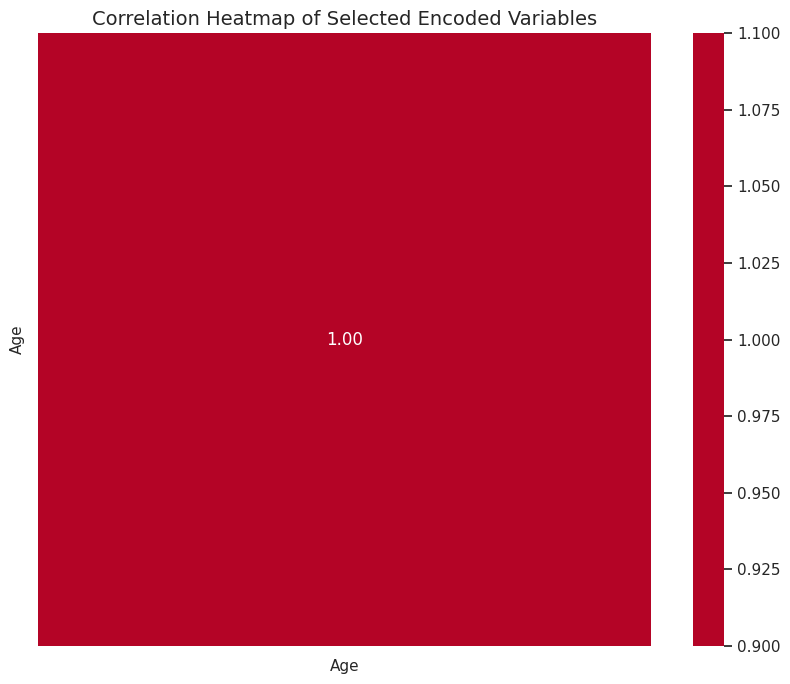

In [33]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Selected Encoded Variables')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for quickly identifying the direction and relative strength of relationships among selected numerical/encoded variables.

The heatmap uses selected encoded variables because correlation requires numerical inputs. Family history and treatment show a comparatively stronger positive association than most other selected variables. The heatmap should be interpreted as exploratory evidence, not a causal model.

The encoded analysis shows that family history has a notably positive association with treatment. The remaining workplace variables generally show weaker relationships with treatment than family history.

#### Chart - 15 - Pair Plot

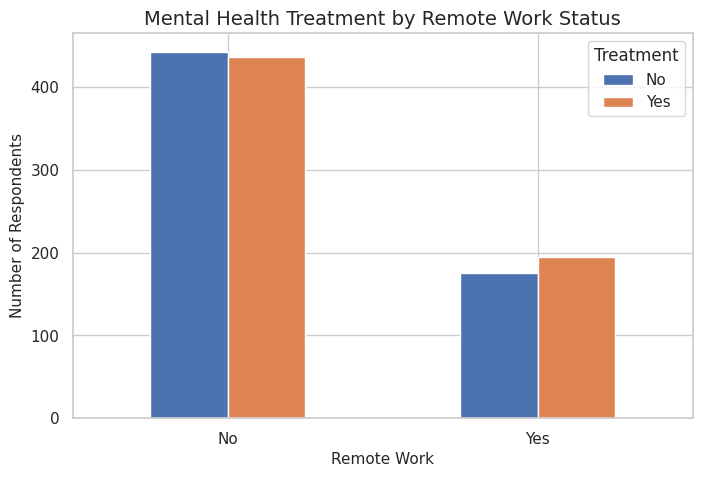

In [35]:

import matplotlib.pyplot as plt
import pandas as pd

table = pd.crosstab(df['remote_work'], df['treatment'])

table.plot(kind='bar', figsize=(8, 5))

plt.title('Mental Health Treatment by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot provides a compact visual overview of pairwise relationships and distributions among selected numerical and binary-encoded variables.

The pair plot provides a visual overview of distributions and pairwise patterns. It supports the broader EDA finding that family history and treatment have a clearer relationship than age or remote-work status. Because several variables are binary encodings, discrete clusters are expected.

The pair plot reinforces that treatment and family history have a visible relationship, while the relationships involving age and remote work are less pronounced. Binary variables form discrete clusters because they are encoded as 0/1.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

### Recommendations

1. **Improve awareness of existing benefits:** A substantial group of respondents does not know whether mental-health benefits are available. Employers should communicate benefit availability and access steps clearly during onboarding and through internal resources.

2. **Make care pathways easy to find:** Respondents who know their employer's care options show a higher treatment rate than those who do not know or are unsure. A simple, centralized mental-health resource page can reduce information barriers.

3. **Strengthen confidentiality communication:** The survey contains substantial uncertainty about anonymity. Employers should explain confidentiality and privacy processes accurately and clearly.

4. **Support managers and supervisors:** Willingness to discuss mental health with supervisors is mixed. Manager training can focus on respectful conversations, appropriate referral to professional resources, and avoiding pressure for personal disclosure.

5. **Normalize mental-health support:** The large number of respondents who are unsure whether mental health is treated as seriously as physical health indicates an opportunity to make mental-health policies more visible and consistent.

6. **Use targeted analysis for different employee groups:** Family history is strongly associated with treatment in the survey, while remote-work status shows a much smaller difference. Organizations should avoid one-size-fits-all assumptions and use multiple workplace factors when designing support programs.

These recommendations are based on associations in the survey and should be validated with current organizational data before being used for policy decisions.

# **Conclusion**

The Mental Health in Tech Survey provides useful evidence about how technology workers experience and perceive mental-health support in the workplace. The EDA shows that treatment status is relatively balanced in the dataset, while several workplace and personal factors are associated with treatment-seeking behavior.

The strongest descriptive relationship examined is between **family history and treatment**: respondents reporting a family history of mental illness have a much higher treatment rate than respondents reporting no family history. Workplace support variables also show useful patterns. Respondents who report mental-health benefits or who know their employer's care options generally show higher treatment rates than respondents who report no benefits or uncertainty about available options.

The analysis also identifies communication gaps. Many respondents are only conditionally willing to discuss mental-health issues with coworkers, willingness to discuss the issue with supervisors is mixed, and most respondents would not bring up a mental-health issue during a job interview. In addition, 'Don't know' is the largest response when respondents are asked whether their employer takes mental health as seriously as physical health.

Overall, the EDA suggests that **awareness, accessibility, confidentiality communication, and workplace culture** are important areas for further attention. The findings are descriptive and observational, so they identify associations rather than causal relationships. The next step would be to validate these patterns using more recent and organization-specific data, followed by an interactive Streamlit dashboard for decision-makers.